<a href="https://colab.research.google.com/github/WarishAli1/Academic-Projects/blob/main/AI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Warish Ali

Roll : ACE079BCT079

BCT B

AI Project


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer as timer
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import random
import seaborn as sns
from sklearn.metrics import classification_report
import pandas as pd

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [4]:
from torchvision.transforms.transforms import ToTensor

transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5),
                         std=(0.5, 0.5, 0.5))
])

train_data = datasets.CIFAR10(root="data",
                              train=True,
                              download=True,
                              transform=transform,
                              target_transform=None)

test_data = datasets.CIFAR10(root="data",
                             train=False,
                             download=True,
                             transform=transform,
                             target_transform=None)

class_names = train_data.classes
BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of testing batches: {len(test_dataloader)}")

100%|██████████| 170M/170M [00:18<00:00, 9.08MB/s]


Number of training batches: 1563
Number of testing batches: 313


In [5]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    return (correct / len(y_pred)) * 100

def train_step(model, data_loader, loss_fn, optimizer, accuracy_fn, device=device):
    model.train()
    train_loss, train_acc = 0, 0
    for X, y in data_loader:
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    return train_loss/len(data_loader), train_acc/len(data_loader)

def test_step(model, data_loader, loss_fn, accuracy_fn, device=device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y).item()
            test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
    return test_loss/len(data_loader), test_acc/len(data_loader)

def eval_model(model, data_loader, loss_fn, accuracy_fn, device=device):
    test_loss, test_acc = test_step(model, data_loader, loss_fn, accuracy_fn, device)
    return {"model_name": model.__class__.__name__,
            "model_loss": test_loss,
            "model_acc": test_acc}

def print_train_time(start, end, device):
    total_time = end - start
    print(f"Training time on {device}: {total_time:.2f} seconds")
    return total_time

def make_predictions(model, data, device=device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            sample = torch.unsqueeze(sample, dim=0).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
            pred_probs.append(pred_prob.cpu())
    return torch.stack(pred_probs)

In [6]:
class SimpleNN(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_shape, hidden_units)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_units, output_shape)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [7]:
class TinyVGG(nn.Module):
    def __init__(self, input_channels, hidden_units, output_shape):
        super().__init__()
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_channels, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units*8*8, output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [8]:
class AlexNetCIFAR(nn.Module):
    def __init__(self, input_channels, output_shape):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, output_shape)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [10]:
models = {
    "SimpleNN": SimpleNN(3*32*32, 512, len(class_names)).to(device),
    "TinyVGG": TinyVGG(input_channels=3, hidden_units=32, output_shape=len(class_names)).to(device),
    "AlexNet": AlexNetCIFAR(input_channels=3, output_shape=len(class_names)).to(device)
}

loss_fn = nn.CrossEntropyLoss()

results = {}

for model_name, model in models.items():
    print(f"\n--- TRAINING {model_name} ---")
    total_params = count_parameters(model)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    start_time = timer()
    EPOCHS = 15
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, accuracy_fn, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, accuracy_fn, device)
        print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    end_time = timer()
    total_time = print_train_time(start_time, end_time, device)

    results[model_name] = {
        "model_name": model_name,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "train_time": total_time,
        "parameters": total_params
    }



--- TRAINING SimpleNN ---
Epoch 1/15: Train Loss: 1.8492 | Train Acc: 33.41% | Test Loss: 1.7715 | Test Acc: 36.90%
Epoch 2/15: Train Loss: 1.7588 | Train Acc: 37.73% | Test Loss: 1.6989 | Test Acc: 40.38%
Epoch 3/15: Train Loss: 1.7306 | Train Acc: 38.89% | Test Loss: 1.7115 | Test Acc: 39.88%
Epoch 4/15: Train Loss: 1.7128 | Train Acc: 39.64% | Test Loss: 1.6886 | Test Acc: 41.39%
Epoch 5/15: Train Loss: 1.7062 | Train Acc: 40.42% | Test Loss: 1.6790 | Test Acc: 41.80%
Epoch 6/15: Train Loss: 1.7019 | Train Acc: 41.04% | Test Loss: 1.6930 | Test Acc: 40.22%
Epoch 7/15: Train Loss: 1.6944 | Train Acc: 40.96% | Test Loss: 1.6628 | Test Acc: 42.45%
Epoch 8/15: Train Loss: 1.6766 | Train Acc: 41.81% | Test Loss: 1.6801 | Test Acc: 40.66%
Epoch 9/15: Train Loss: 1.6694 | Train Acc: 41.95% | Test Loss: 1.6811 | Test Acc: 42.05%
Epoch 10/15: Train Loss: 1.6633 | Train Acc: 41.97% | Test Loss: 1.6706 | Test Acc: 42.11%
Epoch 11/15: Train Loss: 1.6592 | Train Acc: 42.45% | Test Loss: 1.6625 

# Improvements made by AlexNet over its predecessors.  
One of the main improvements of AlexNet over earlier neural networks was the use of ReLU activation, which made training much faster and reduced the vanishing gradient problem. Another important improvement was dropout in the fully connected layers. Dropout randomly turns off some neurons during training, which helps prevent overfitting and improves generalization. I also used dropout in my AlexNet model, and it helped the model perform better on the test set.

AlexNet also used data augmentation, such as random cropping and horizontal flipping, to increase the effective size of the training dataset. This makes the model more robust and improves accuracy. In addition, AlexNet has a deeper architecture with multiple convolutional layers, allowing it to learn more complex image features. Because of these improvements, my AlexNet model achieved better performance compared to SimpleNN and TinyVGG.

In [11]:
final_results = pd.DataFrame(results).T
final_results = final_results[[
    "train_acc",
    "test_acc",
    "train_loss",
    "test_loss",
    "train_time",
    "parameters"
]]

print(final_results)

          train_acc   test_acc train_loss test_loss  train_time parameters
SimpleNN  43.060221  41.453674     1.6475  1.693311   409.79608    1578506
TinyVGG   72.126919  72.214457   0.797213  0.815429  480.991367      49130
AlexNet   87.010157  83.716054   0.391265  0.496666  606.692861    6976842


# Explanation:
AlexNet performs the best, with the highest training accuracy (87.01%) and test accuracy (83.72%), and the lowest loss values. This means it learns the data very well and generalizes better than the other two models. However, it also has the largest number of parameters (6.9 million) and the longest training time (about 607 seconds), making it the most computationally expensive model.

TinyVGG achieves moderate performance with around 72% test accuracy. It uses very few parameters (about 49k) compared to the other models, showing that it is efficient and provides a good balance between accuracy and model size.

SimpleNN has the lowest accuracy (41.45% test) and the highest loss values, even though it has more parameters than TinyVGG. This shows that fully connected networks are not effective for image classification compared to convolutional neural networks.

Overall, the table highlights the trade-off between accuracy, training time, and model complexity among the three models.

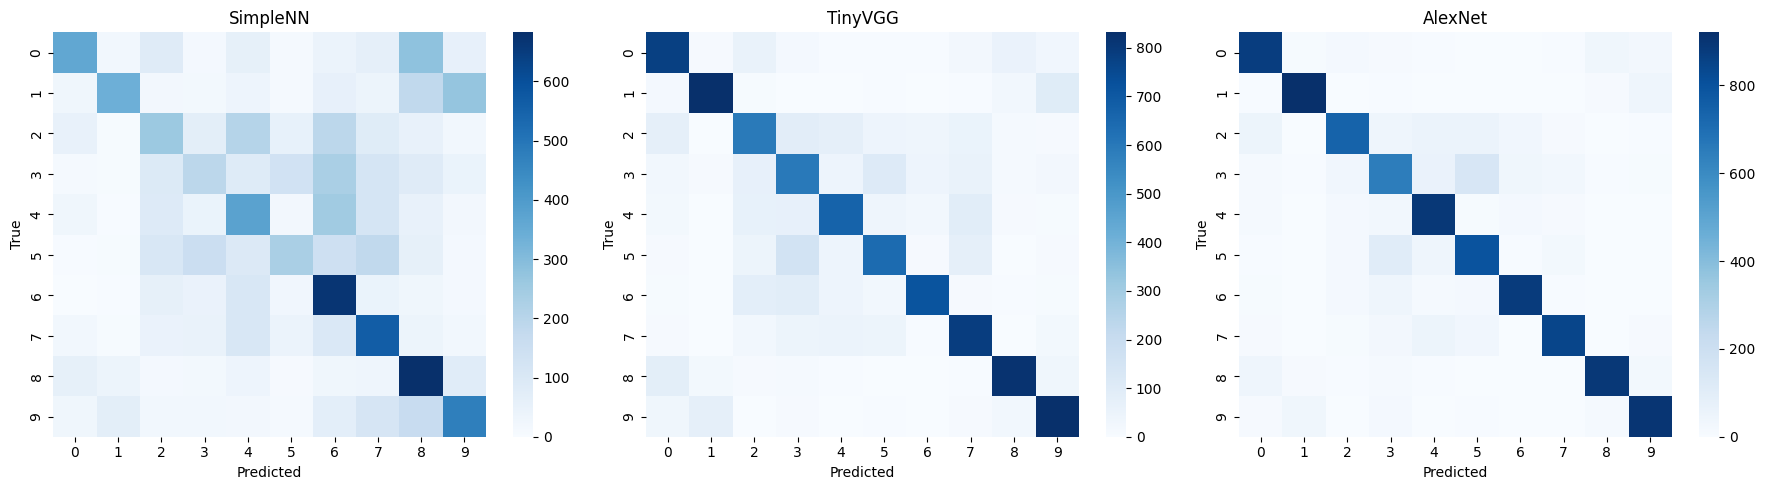

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for idx, (model_name, model) in enumerate(models.items()):

    all_preds = []
    all_labels = []

    model.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            X = X.to(device)
            preds = torch.argmax(model(X), dim=1)
            all_preds.append(preds.cpu())
            all_labels.append(y)

    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels)

    confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
    cm = confmat(preds, labels).numpy()

    sns.heatmap(cm, annot=False, cmap="Blues", ax=axes[idx])
    axes[idx].set_title(model_name)
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("True")

plt.tight_layout()
plt.show()

In [13]:
for model_name, model in models.items():
    print(f"\n=== {model_name} Classification Report ===")

    all_preds = []
    all_labels = []

    model.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            X = X.to(device)
            preds = torch.argmax(model(X), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.numpy())

    print(classification_report(all_labels, all_preds, target_names=class_names))


=== SimpleNN Classification Report ===
              precision    recall  f1-score   support

    airplane       0.62      0.35      0.45      1000
  automobile       0.65      0.34      0.45      1000
        bird       0.33      0.27      0.30      1000
         cat       0.31      0.21      0.25      1000
        deer       0.36      0.40      0.37      1000
         dog       0.42      0.23      0.30      1000
        frog       0.39      0.67      0.49      1000
       horse       0.41      0.57      0.48      1000
        ship       0.41      0.67      0.50      1000
       truck       0.46      0.46      0.46      1000

    accuracy                           0.42     10000
   macro avg       0.44      0.42      0.40     10000
weighted avg       0.44      0.42      0.40     10000


=== TinyVGG Classification Report ===
              precision    recall  f1-score   support

    airplane       0.71      0.77      0.74      1000
  automobile       0.87      0.85      0.86      1000

# Explanations:
From the classification reports, AlexNet performs the best overall, with high precision, recall, and F1-scores across all classes (around 0.84–0.94), showing it predicts most classes correctly and consistently. Its deeper architecture, dropout, and data augmentation help it generalize well and reduce overfitting.

TinyVGG performs moderately, with test accuracy around 72%. Precision and recall are lower for more difficult classes like cat and bird, but the model is efficient, with very few parameters, showing that even small CNNs can capture image features better than fully connected networks.

SimpleNN performs the worst, with low accuracy (41%) and poor precision and recall for most classes. It struggles to identify similar classes (like cat vs dog) because it cannot capture spatial patterns in images.

Here, I used accuracy, precision, recall, and F1-score because it provides a full picture: accuracy shows overall correctness, while precision and recall highlight class-wise performance and misclassification patterns. F1-score balances precision and recall, giving a more complete evaluation, especially for classes that are harder to classify.

# Discussion
In this project, three models (SimpleNN, TinyVGG, and AlexNet) were trained and evaluated on the CIFAR-10 dataset. The results show that convolutional neural networks performed better than the simple fully connected neural network. SimpleNN had the lowest accuracy because it cannot capture spatial features in images. TinyVGG improved performance by using convolutional layers, which helped the model learn image patterns such as edges and shapes.

AlexNet achieved the best performance among the three models. This is because it uses a deeper architecture, ReLU activation, dropout, and data augmentation techniques inspired by the original ImageNet Classification with Deep Convolutional Neural Networks. Data augmentation (RandomCrop and RandomHorizontalFlip) improved generalization by creating more varied training samples. Dropout in the fully connected layers reduced overfitting. Hyperparameter tuning, such as reducing the learning rate from 0.1 to 0.01 and increasing the number of epochs from 5 to 15, also improved convergence and stability during training.

Although AlexNet required more training time and had more parameters, it provided better accuracy and generalization compared to the other two models.


# Conclusion
In conclusion, this project demonstrates that deeper convolutional architectures outperform simple neural networks for image classification tasks. The SimpleNN model was faster but less accurate, while TinyVGG provided a good balance between efficiency and performance. AlexNet achieved the highest accuracy due to its deeper structure, dropout regularization, and data augmentation techniques.

Overall, proper model design, regularization, and hyperparameter tuning significantly improve performance. The experiment confirms that more advanced CNN architectures are more effective for image classification, even though they require more computational resources.

In [1]:
!pip install torchmetrics mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 58.8 MB/s eta 0:00:00
